1. Importar librerias y cargar datos

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Cargar el dataset .xls
df = pd.read_excel('data/AmesHousing.xls')

print("✅ Dataset cargado correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

✅ Dataset cargado correctamente
Filas: 2930
Columnas: 82


2. Ver las primeras filas

In [6]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


3. Tipos de variables

In [7]:
print("=== VARIABLES NUMÉRICAS ===")
numericas = df.select_dtypes(include='number').columns.tolist()
print(f"Cantidad: {len(numericas)}")
print(numericas)

print("\n=== VARIABLES CATEGÓRICAS ===")
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f"Cantidad: {len(categoricas)}")
print(categoricas)

=== VARIABLES NUMÉRICAS ===
Cantidad: 39
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

=== VARIABLES CATEGÓRICAS ===
Cantidad: 43
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure

C:\Users\Natalia\AppData\Local\Temp\ipykernel_23304\597339767.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


4. Valores Nulos 

In [8]:
# Ver cuántos nulos hay antes
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje.round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print("=== COLUMNAS CON VALORES NULOS (ANTES) ===")
print(missing[missing['Valores nulos'] > 0])

# Separar columnas numéricas y categóricas
numericas = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

# Imputar nulos en columnas NUMÉRICAS con KNN
imputer = KNNImputer(n_neighbors=5)
df_num_imputado = pd.DataFrame(
    imputer.fit_transform(df[numericas]),
    columns=numericas
)

# Para columnas CATEGÓRICAS imputamos con la moda (valor más frecuente)
df_cat_imputado = df[categoricas].fillna(df[categoricas].mode().iloc[0])

# Reconstruir el dataframe completo
df_limpio = pd.concat([df_num_imputado, df_cat_imputado], axis=1)

# Verificar que no queden nulos
print("\n=== VALORES NULOS DESPUÉS DE IMPUTACIÓN ===")
print(f"Total de nulos restantes: {df_limpio.isnull().sum().sum()}")

=== COLUMNAS CON VALORES NULOS (ANTES) ===
                Valores nulos  Porcentaje (%)
Pool QC                  2917           99.56
Misc Feature             2824           96.38
Alley                    2732           93.24
Fence                    2358           80.48
Mas Vnr Type             1775           60.58
Fireplace Qu             1422           48.53
Lot Frontage              490           16.72
Garage Qual               159            5.43
Garage Yr Blt             159            5.43
Garage Cond               159            5.43
Garage Finish             159            5.43
Garage Type               157            5.36
Bsmt Exposure              83            2.83
BsmtFin Type 2             81            2.76
Bsmt Qual                  80            2.73
Bsmt Cond                  80            2.73
BsmtFin Type 1             80            2.73
Mas Vnr Area               23            0.78
Bsmt Full Bath              2            0.07
Bsmt Half Bath              2        

C:\Users\Natalia\AppData\Local\Temp\ipykernel_23304\2294600413.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()



=== VALORES NULOS DESPUÉS DE IMPUTACIÓN ===
Total de nulos restantes: 0


5. Estadísticas descriptivas

In [9]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00,2.930000e+03,2930.00,2440.00,2930.00,2930.00,2930.00,2930.00,2930.00,2907.00,...,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00
mean,1465.50,7.144645e+08,57.39,69.22,10147.92,6.09,5.56,1971.36,1984.27,101.90,...,93.75,47.53,23.01,2.59,16.00,2.24,50.64,6.22,2007.79,180796.06
std,845.96,1.887308e+08,42.64,23.37,7880.02,1.41,1.11,30.25,20.86,179.11,...,126.36,67.48,64.14,25.14,56.09,35.60,566.34,2.71,1.32,79886.69
min,1.00,5.263011e+08,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,12789.00
25%,733.25,5.284770e+08,20.00,58.00,7440.25,5.00,5.00,1954.00,1965.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2007.00,129500.00
50%,1465.50,5.354536e+08,50.00,68.00,9436.50,6.00,5.00,1973.00,1993.00,0.00,...,0.00,27.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,160000.00
75%,2197.75,9.071811e+08,70.00,80.00,11555.25,7.00,6.00,2001.00,2004.00,164.00,...,168.00,70.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,213500.00
max,2930.00,1.007100e+09,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,...,1424.00,742.00,1012.00,508.00,576.00,800.00,17000.00,12.00,2010.00,755000.00


6. Gráfico: distribución del precio de venta

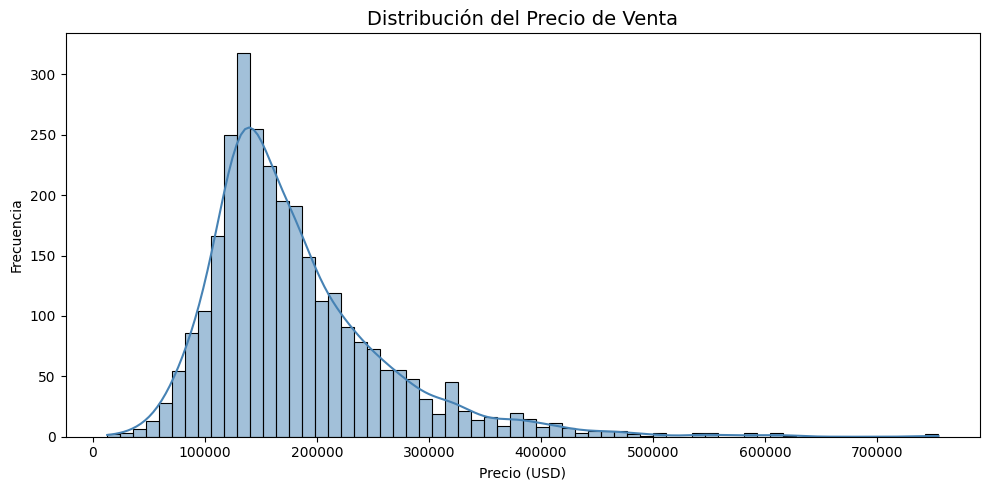

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('Distribución del Precio de Venta', fontsize=14)
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

7.  Gráfico: mapa de correlaciones

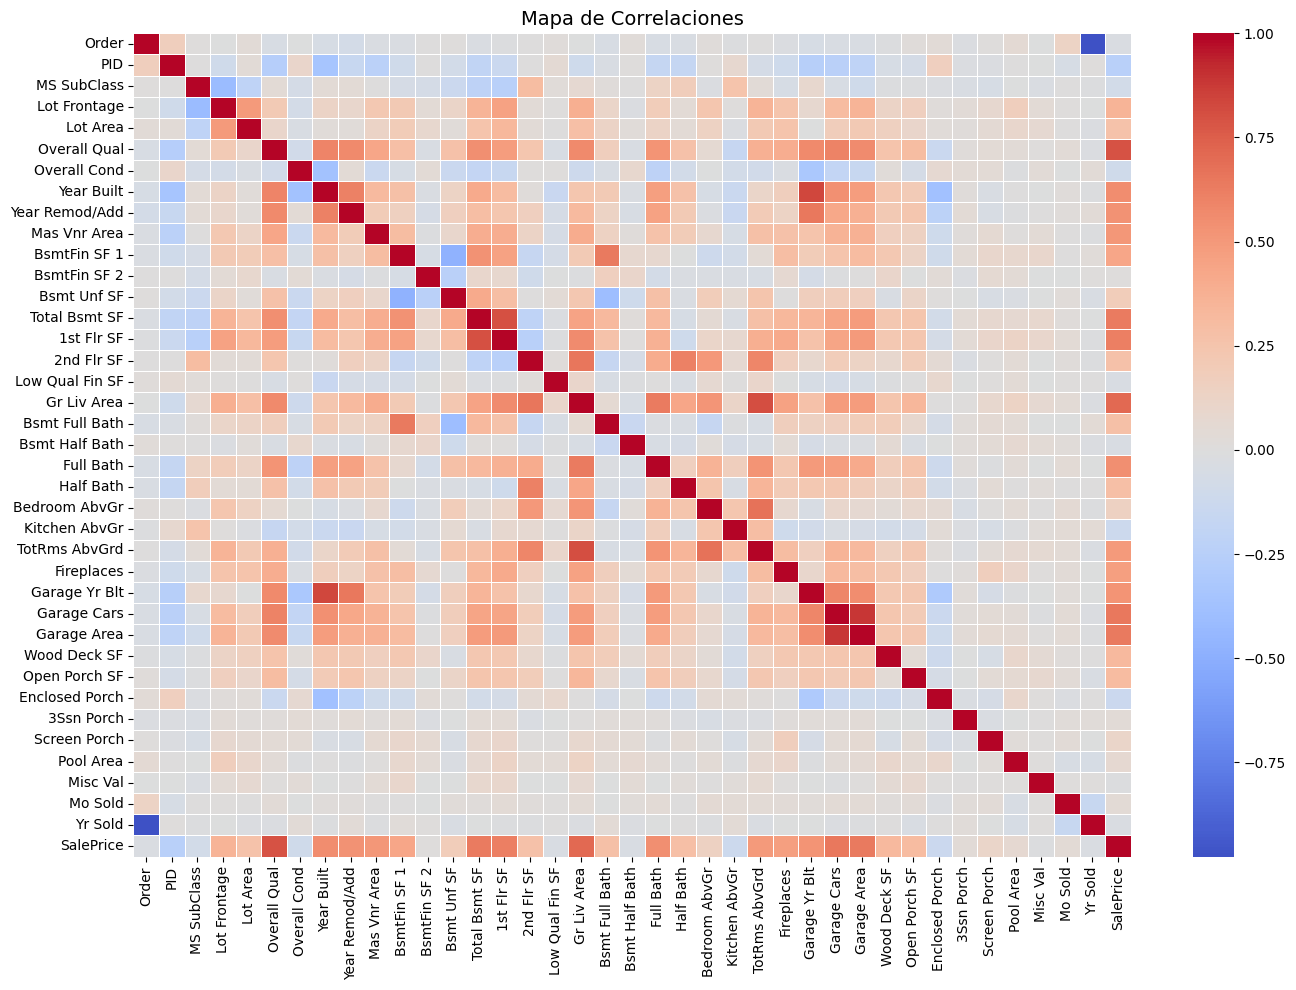

In [ ]:
plt.figure(figsize=(14, 10))
corr = df_limpio.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

8. Top 10 variables más correlacionadas con el precio

In [ ]:
correlaciones = corr['SalePrice'].sort_values(ascending=False)
print("=== TOP 10 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE ===")
print(correlaciones.head(11))

=== TOP 10 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE ===
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64
